<a href="https://colab.research.google.com/github/Purshottambadwaik/Salary-Prediction/blob/main/model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Machine Learning Concepts

### Date
*   ML 21-04-2026

### Types of Machine Learning
*   **Supervised Learning**: Data is labeled.
*   **Unsupervised Learning**: Data is unlabeled.
*   **Reinforcement Learning**: Agent learns through trial and error.

### Overfitting and Underfitting
*   **Overfitting**: Occurs when a model learns the training data too well, including noise, leading to poor generalization. Methods like Ridge and Lasso regression can help.
*   **Underfitting**: Occurs when a model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and test sets.

### Classification
*   **Binary Classification**: (e.g., yes/no prediction)

### Regression Metrics
*   Mean Absolute Error (MAE)
*   Mean Squared Error (MSE)
*   Root Mean Squared Error (RMSE)
*   R2 Score

### Algorithms (mentioned)
*   K-Nearest Neighbors (KNN)

# New Section

AGENT MAKING
model.pkl

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/Salary_Data (1).csv')

In [ ]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
numerical_cols = ['Age', 'Years of Experience', 'Salary']
categorical_cols = ['Gender', 'Education Level', 'Job Title']

# Impute numerical columns with mean
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().any():
        # .mode()[0] handles cases where there might be multiple modes
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify that null values have been handled
print('Null values after imputation:')
print(df.isnull().sum())

Null values after imputation:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6704 non-null   float64
 1   Gender               6704 non-null   object 
 2   Education Level      6704 non-null   object 
 3   Job Title            6704 non-null   object 
 4   Years of Experience  6704 non-null   float64
 5   Salary               6704 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


## Duplicate Removal

In [ ]:
print(f"Shape of DataFrame before removing duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after removing duplicates: {df.shape}")

Shape of DataFrame before removing duplicates: (6704, 6)
Shape of DataFrame after removing duplicates: (1792, 6)


In [ ]:
pass

## Model Building

Before training the models, we need to preprocess the categorical features using one-hot encoding and then split the data into training and testing sets.

In [ ]:
# Import necessary libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Identify numerical and categorical columns for preprocessing
numerical_features = ['Age', 'Years of Experience']
categorical_features = ['Gender', 'Education Level', 'Job Title']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete: Features and target defined, data split, and preprocessors set up.")

Data preparation complete: Features and target defined, data split, and preprocessors set up.


### 1. Linear Regression

In [ ]:
# Create a pipeline that first preprocesses the data and then applies Linear Regression
linear_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', LinearRegression())])

# Train the model
linear_reg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_reg_pipeline.predict(X_test)

# Evaluate the model
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression R2 Score: {r2_lr:.4f}")
print(f"Linear Regression Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression Mean Absolute Error: {mae_lr:.2f}")

Linear Regression R2 Score: 0.8793
Linear Regression Mean Squared Error: 322424713.42
Linear Regression Mean Absolute Error: 12574.22


### 2. Decision Tree Regression

In [ ]:
# Create a pipeline for Decision Tree Regressor
decision_tree_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', DecisionTreeRegressor(random_state=42))])

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_pipeline.predict(X_test)

# Evaluate the model
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print(f"Decision Tree R2 Score: {r2_dt:.4f}")
print(f"Decision Tree Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree Mean Absolute Error: {mae_dt:.2f}")

Decision Tree R2 Score: 0.9750
Decision Tree Mean Squared Error: 66712889.32
Decision Tree Mean Absolute Error: 2668.56


### 3. Random Forest Regression

In [ ]:
# Create a pipeline for Random Forest Regressor
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', RandomForestRegressor(random_state=42))])

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_pipeline.predict(X_test)

# Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest R2 Score: {r2_rf:.4f}")
print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Mean Absolute Error: {mae_rf:.2f}")

Random Forest R2 Score: 0.9809
Random Forest Mean Squared Error: 51143420.34
Random Forest Mean Absolute Error: 2756.34


### 4. Support Vector Machine (SVR)

In [ ]:
# Create a pipeline for SVR
# Note: StandardScaler is already part of the preprocessor, so it's applied to numerical features before SVR
svr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', SVR(kernel='rbf'))]) # Using Radial Basis Function kernel

# Train the model
svr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_svr = svr_pipeline.predict(X_test)

# Evaluate the model
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print(f"SVR R2 Score: {r2_svr:.4f}")
print(f"SVR Mean Squared Error: {mse_svr:.2f}")
print(f"SVR Mean Absolute Error: {mae_svr:.2f}")

SVR R2 Score: 0.0122
SVR Mean Squared Error: 2638012015.24
SVR Mean Absolute Error: 44445.16


### 5. K-Nearest Neighbors (KNN) Regression

In [ ]:
# Create a pipeline for KNN Regressor
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', KNeighborsRegressor(n_neighbors=5))]) # Using 5 neighbors

# Train the model
knn_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the model
r2_knn = r2_score(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print(f"KNN R2 Score: {r2_knn:.4f}")
print(f"KNN Mean Squared Error: {mse_knn:.2f}")
print(f"KNN Mean Absolute Error: {mae_knn:.2f}")

KNN R2 Score: 0.9689
KNN Mean Squared Error: 82926447.20
KNN Mean Absolute Error: 3886.22


## Model Comparison

Let's summarize the performance of all models.

In [ ]:
model_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN'],
    'R2 Score': [r2_lr, r2_dt, r2_rf, r2_svr, r2_knn],
    'MSE': [mse_lr, mse_dt, mse_rf, mse_svr, mse_knn],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_svr, mae_knn]
})

model_performance = model_performance.sort_values(by='R2 Score', ascending=False)
display(model_performance)

,Model,R2 Score,MSE,MAE
2,Random Forest,0.980850,5.114342e+07,2756.339171
1,Decision Tree,0.975020,6.671289e+07,2668.556213
4,KNN,0.968949,8.292645e+07,3886.224679
0,Linear Regression,0.879273,3.224247e+08,12574.216706
3,SVR,0.012236,2.638012e+09,44445.157592


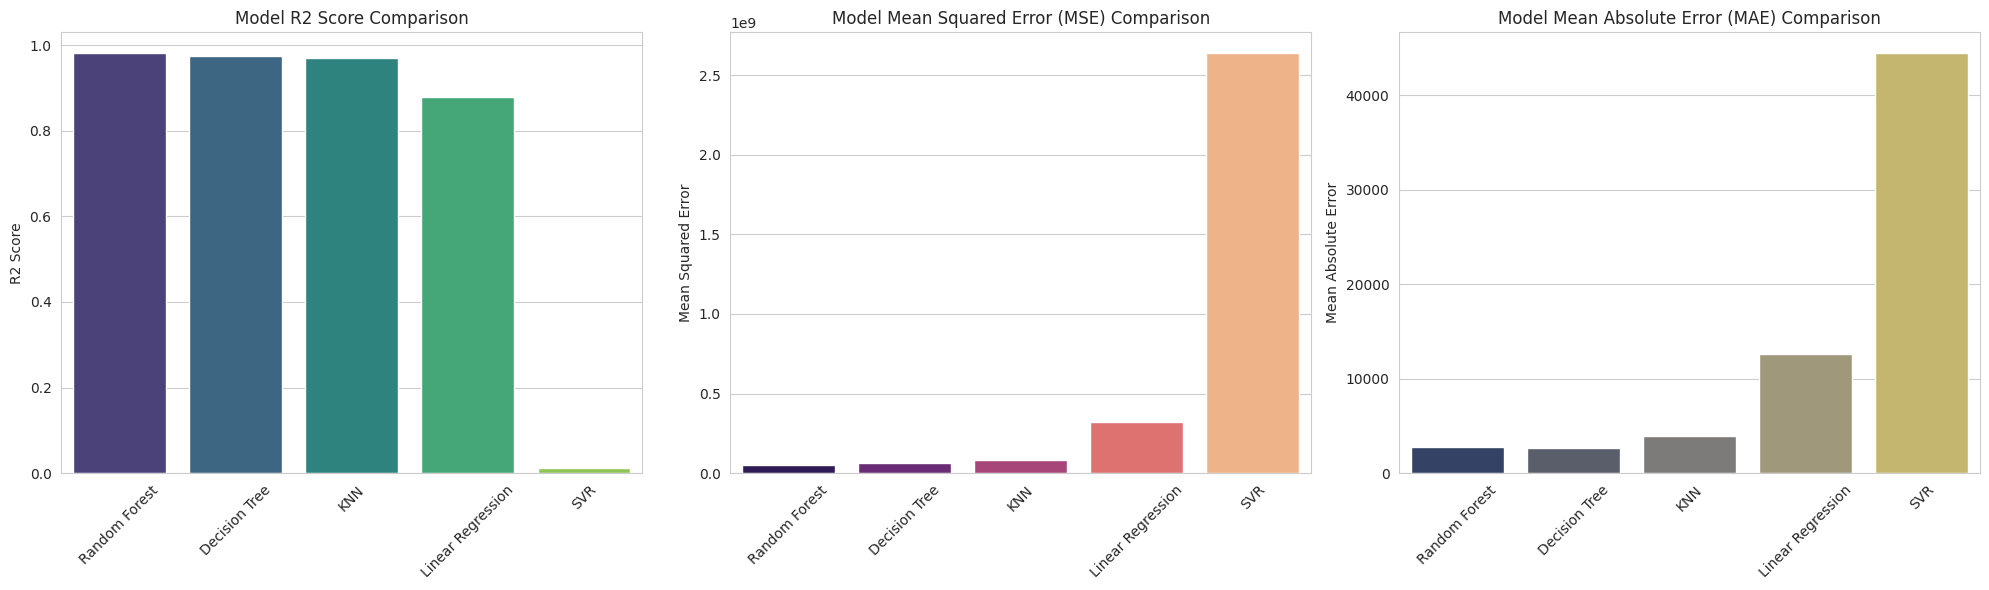

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create subplots for R2 Score, MSE, and MAE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot R2 Score
sns.barplot(x='Model', y='R2 Score', data=model_performance, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Model R2 Score Comparison')
axes[0].set_ylabel('R2 Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Plot MSE
sns.barplot(x='Model', y='MSE', data=model_performance, ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Model Mean Squared Error (MSE) Comparison')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(x='Model', y='MAE', data=model_performance, ax=axes[2], palette='cividis', hue='Model', legend=False)
axes[2].set_title('Model Mean Absolute Error (MAE) Comparison')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
pass

## Saving the Best Model

Based on the comparison, the Random Forest Regressor performed the best. We will now save this model using `joblib` for future use.

In [ ]:
import joblib

# Define the filename for the saved model
model_filename = 'best_model.pkl'

# Save the best model (Random Forest pipeline) to a .pkl file
joblib.dump(random_forest_pipeline, model_filename)

print(f"The best model (Random Forest Regressor) has been saved to {model_filename}")

The best model (Random Forest Regressor) has been saved to best_model.pkl


### Applying Label Encoding

Label encoding converts categorical labels into numerical format. It assigns a unique integer to each category. This is different from one-hot encoding, which creates new binary columns for each category.

Here, we will apply `LabelEncoder` to the categorical columns (`Gender`, `Education Level`, `Job Title`) to demonstrate its usage. We'll work on a copy of the DataFrame to keep the previous model training unaffected.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the DataFrame to apply Label Encoding without altering the original df
df_encoded = df.copy()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_features:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

print("DataFrame after applying Label Encoding to categorical features:")
display(df_encoded.head())

DataFrame after applying Label Encoding to categorical features:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,177,5.0,90000.0
1,28.0,0,3,18,3.0,65000.0
2,45.0,1,5,145,15.0,150000.0
3,36.0,0,0,116,7.0,60000.0
4,52.0,1,3,26,20.0,200000.0
